In [22]:
!pip install tensorflow

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
import os
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

In [41]:
def load_raw(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["Date_Heure"] = pd.to_datetime(df["Date_Heure"])
    return df

In [42]:
df=load_raw("/content/donnees_synthetiques_tollxpress_benin_2023-2024.csv")

In [43]:
def _add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["heure"]        = df["date"].dt.hour
    df["jour_semaine"] = df["date"].dt.dayofweek      # 0=lundi
    df["jour_mois"]    = df["date"].dt.day
    df["mois"]         = df["date"].dt.month
    df["est_weekend"]  = (df["jour_semaine"] >= 5).astype(int)
    # encodage cyclique de l'heure (sin/cos) → meilleur pour LSTM
    df["heure_sin"]    = np.sin(2 * np.pi * df["heure"] / 24)
    df["heure_cos"]    = np.cos(2 * np.pi * df["heure"] / 24)
    df["mois_sin"]     = np.sin(2 * np.pi * df["mois"]  / 12)
    df["mois_cos"]     = np.cos(2 * np.pi * df["mois"]  / 12)
    return df

In [44]:
def _add_lags_rolling(df: pd.DataFrame, col: str, lags: list, windows: list) -> pd.DataFrame:
    df = df.copy()
    # lags
    for lag in lags:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)
    # rolling mean / std sur les dernières `w` périodes
    for w in windows:
        df[f"{col}_roll_mean_{w}"] = df[col].shift(1).rolling(w).mean()
        df[f"{col}_roll_std_{w}"]  = df[col].shift(1).rolling(w).std()
        df[f"{col}_roll_max_{w}"]  = df[col].shift(1).rolling(w).max()
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

In [45]:
def preprocess_vehicules_par_heure(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Retourne un DataFrame horaire avec :
      - nb_vehicules         : nombre de passages par heure  ← cible LSTM
      - features temporelles (sin/cos heure, weekend, …)
      - lags : t-1, t-2, t-3, t-24 (même heure hier), t-168 (même heure semaine passée)
      - rolling mean/std/max sur 3, 6, 24 dernières heures
    """
    df = df_raw.copy()
    df["date_heure"] = df["Date_Heure"].dt.floor("h")

    agg = (
        df.groupby("date_heure")
          .agg(nb_vehicules=("ID_transaction", "count"))
          .reset_index()
          .rename(columns={"date_heure": "date"})
    )

    # compléter les heures manquantes (pas de trafic = 0)
    full_idx = pd.date_range(agg["date"].min(), agg["date"].max(), freq="h")
    agg = agg.set_index("date").reindex(full_idx, fill_value=0).reset_index()
    agg.rename(columns={"index": "date"}, inplace=True)

    # features temporelles
    agg = _add_time_features(agg)

    # lags + rolling
    lags    = [1, 2, 3, 24, 168]   # 1h, 2h, 3h, hier même heure, semaine passée
    windows = [3, 6, 24]
    agg = _add_lags_rolling(agg, "nb_vehicules", lags=lags, windows=windows)

    return agg

In [46]:
    lags    = [1, 2, 3, 7]        # 1j, 2j, 3j, semaine passée
    windows = [3, 7, 14]

In [47]:
PATH = "donnees_synthetiques_tollxpress_benin_2023-2024.csv"
df_raw = load_raw(PATH)
df_heure  = preprocess_vehicules_par_heure(df_raw)
df=_add_time_features(df_heure)
df_preprocessed=_add_lags_rolling(df, "nb_vehicules", lags=lags, windows=windows)



In [48]:
df_preprocessed

,date,nb_vehicules,heure,jour_semaine,jour_mois,mois,est_weekend,heure_sin,heure_cos,mois_sin,...,nb_vehicules_roll_mean_24,nb_vehicules_roll_std_24,nb_vehicules_roll_max_24,nb_vehicules_lag7,nb_vehicules_roll_mean_7,nb_vehicules_roll_std_7,nb_vehicules_roll_max_7,nb_vehicules_roll_mean_14,nb_vehicules_roll_std_14,nb_vehicules_roll_max_14
0,2023-01-08 15:00:00,20,15,6,8,1,1,-0.707107,-7.071068e-01,5.000000e-01,...,13.416667,10.946179,39.0,18.0,14.142857,4.670067,21.0,9.428571,7.772875,21.0
1,2023-01-08 16:00:00,13,16,6,8,1,1,-0.866025,-5.000000e-01,5.000000e-01,...,13.375000,10.917925,39.0,21.0,14.428571,4.995236,21.0,10.857143,7.744548,21.0
2,2023-01-08 17:00:00,17,17,6,8,1,1,-0.965926,-2.588190e-01,5.000000e-01,...,12.958333,10.723721,39.0,15.0,13.285714,4.070802,20.0,11.642857,7.323378,21.0
3,2023-01-08 18:00:00,21,18,6,8,1,1,-1.000000,-1.836970e-16,5.000000e-01,...,12.375000,10.059875,39.0,16.0,13.571429,4.276180,20.0,12.857143,6.619983,21.0
4,2023-01-08 19:00:00,23,19,6,8,1,1,-0.965926,2.588190e-01,5.000000e-01,...,11.625000,8.545594,32.0,11.0,14.285714,5.089672,21.0,14.285714,5.992670,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17355,2024-12-31 18:00:00,18,18,1,31,12,0,-1.000000,-1.836970e-16,-2.449294e-16,...,12.541667,9.788987,30.0,16.0,18.142857,4.947342,28.0,15.642857,7.621903,28.0
17356,2024-12-31 19:00:00,17,19,1,31,12,0,-0.965926,2.588190e-01,-2.449294e-16,...,12.041667,9.143680,28.0,12.0,18.428571,4.859943,28.0,16.857143,6.359211,28.0
17357,2024-12-31 20:00:00,11,20,1,31,12,0,-0.866025,5.000000e-01,-2.449294e-16,...,11.708333,8.789713,28.0,16.0,19.142857,4.059087,28.0,17.857143,4.959174,28.0
17358,2024-12-31 21:00:00,9,21,1,31,12,0,-0.707107,7.071068e-01,-2.449294e-16,...,11.583333,8.777029,28.0,17.0,18.428571,5.028490,28.0,18.142857,4.365197,28.0


In [49]:
df_preprocessed.shape

(17360, 32)

# Lstm model


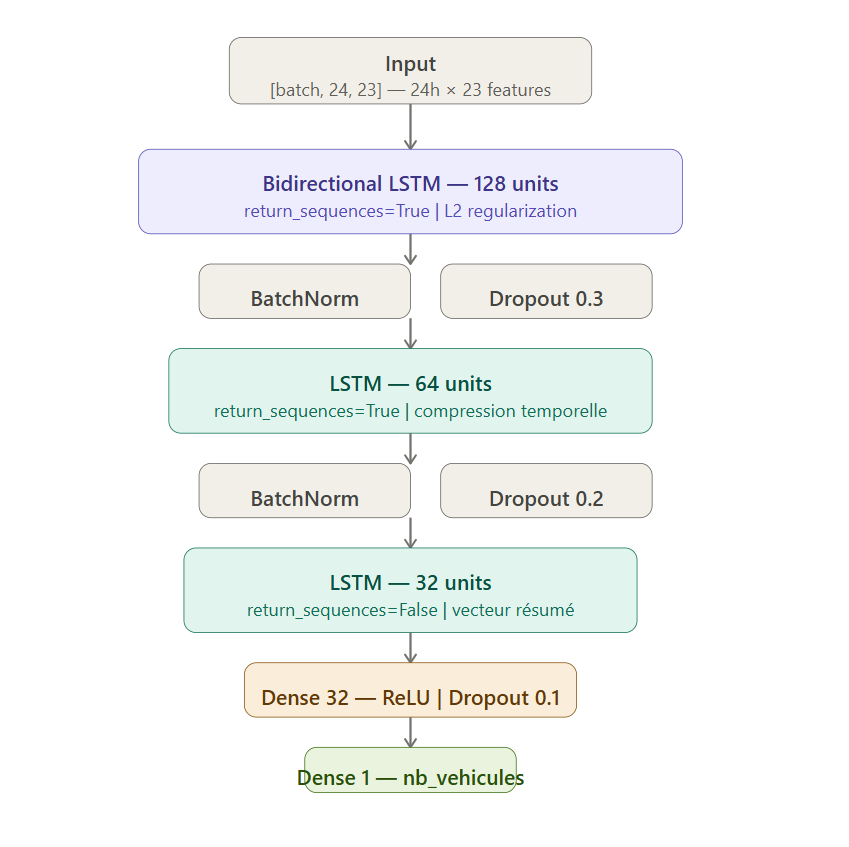

df_heure shape : (17374, 25)
colonnes       : ['date', 'nb_vehicules', 'heure', 'jour_semaine', 'jour_mois', 'mois', 'est_weekend', 'heure_sin', 'heure_cos', 'mois_sin', 'mois_cos', 'nb_vehicules_lag1', 'nb_vehicules_lag2', 'nb_vehicules_lag3', 'nb_vehicules_lag24', 'nb_vehicules_lag168', 'nb_vehicules_roll_mean_3', 'nb_vehicules_roll_std_3', 'nb_vehicules_roll_max_3', 'nb_vehicules_roll_mean_6', 'nb_vehicules_roll_std_6', 'nb_vehicules_roll_max_6', 'nb_vehicules_roll_mean_24', 'nb_vehicules_roll_std_24', 'nb_vehicules_roll_max_24']
X_seq : (17350, 24, 23)  |  y_seq : (17350, 1)
Train : (12145, 24, 23)  |  Val : (2602, 24, 23)  |  Test : (2603, 24, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 256)        │       155,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 24, 64)         │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,737 (987.25 KB)

 Trainable params: 252,033 (984.50 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 35s 139ms/step - loss: 0.1845 - mae: 0.3109 - val_loss: 0.0591 - val_mae: 0.1806 - learning_rate: 0.0010
Epoch 2/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 25s 130ms/step - loss: 0.0636 - mae: 0.1836 - val_loss: 0.0368 - val_mae: 0.1303 - learning_rate: 0.0010
Epoch 3/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 47s 161ms/step - loss: 0.0408 - mae: 0.1422 - val_loss: 0.0235 - val_mae: 0.0887 - learning_rate: 0.0010
Epoch 4/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 28s 145ms/step - loss: 0.0308 - mae: 0.1193 - val_loss: 0.0203 - val_mae: 0.0839 - learning_rate: 0.0010
Epoch 5/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 42s 148ms/step - loss: 0.0243 - mae: 0.1031 - val_loss: 0.0166 - val_mae: 0.0740 - learning_rate: 0.0010
Epoch 6/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 38s 131ms/step - loss: 0.0201 - mae: 0.0916 - val_loss: 0.0153 - val_mae: 0.0687 - learning_rate: 0.0010
Epoch 7/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - loss: 0.0172 - mae: 0.0825 - val_loss: 0.0126 - val_mae: 0.0602 - learnin

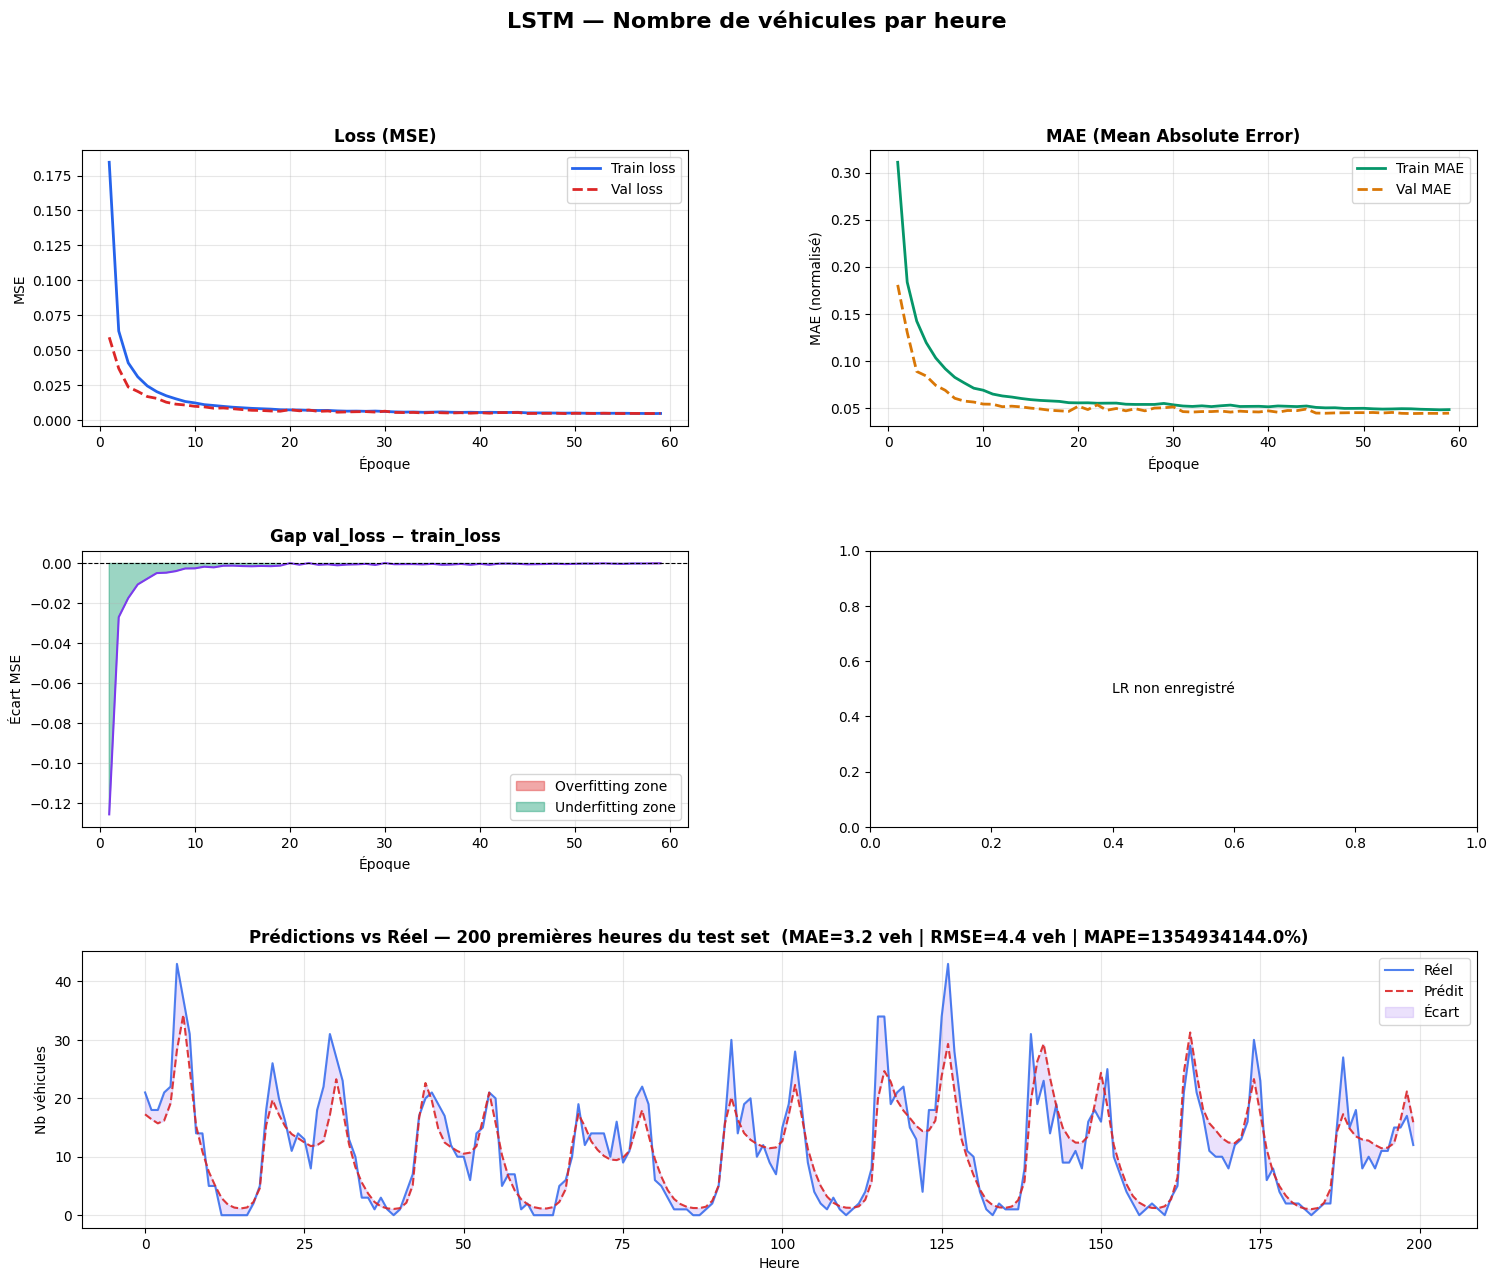

Plot sauvegardé : lstm_heure_training.png
Modèle sauvegardé : lstm_heure.keras


In [50]:


# ════════════════════════════════════════════════════════════════════════════
# 1.  CHARGEMENT & PREPROCESSING
# ════════════════════════════════════════════════════════════════════════════
PATH    = "donnees_synthetiques_tollxpress_benin_2023-2024.csv"
TARGET  = "nb_vehicules"
SEQ_LEN = 24          # fenêtre temporelle : 24 heures passées → prédit h+1

df_raw   = load_raw(PATH)
df_heure = preprocess_vehicules_par_heure(df_raw)

print(f"df_heure shape : {df_heure.shape}")
print(f"colonnes       : {df_heure.columns.tolist()}")

# ════════════════════════════════════════════════════════════════════════════
# 2.  FEATURES & NORMALISATION
# ════════════════════════════════════════════════════════════════════════════
# colonnes à exclure de l'entrainement
EXCLUDE = ["date"]
FEATURE_COLS = [c for c in df_heure.columns if c not in EXCLUDE + [TARGET]]

# on garde la date de côté pour les graphiques
dates = df_heure["date"].values

X_raw = df_heure[FEATURE_COLS].values.astype(np.float32)
y_raw = df_heure[TARGET].values.astype(np.float32).reshape(-1, 1)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

# ════════════════════════════════════════════════════════════════════════════
# 3.  CREATION DES SEQUENCES LSTM  [samples, SEQ_LEN, features]
# ════════════════════════════════════════════════════════════════════════════
def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y_scaled, SEQ_LEN)
print(f"X_seq : {X_seq.shape}  |  y_seq : {y_seq.shape}")

# ════════════════════════════════════════════════════════════════════════════
# 4.  SPLIT  train 70% / val 15% / test 15%  (temporel, pas aléatoire)
# ════════════════════════════════════════════════════════════════════════════
n       = len(X_seq)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X_seq[:n_train],           y_seq[:n_train]
X_val,   y_val   = X_seq[n_train:n_train+n_val], y_seq[n_train:n_train+n_val]
X_test,  y_test  = X_seq[n_train+n_val:],     y_seq[n_train+n_val:]

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}")

# ════════════════════════════════════════════════════════════════════════════
# 5.  ARCHITECTURE LSTM
#
#     Bidirectional LSTM  →  capture les tendances passées ET futures
#     BatchNormalization  →  stabilise l'entraînement
#     Dropout             →  régularisation contre le surapprentissage
#     Dense(32)           →  couche intermédiaire de décision
#     Dense(1)            →  sortie scalaire (régression)
# ════════════════════════════════════════════════════════════════════════════
N_FEATURES = X_train.shape[2]

model = Sequential([
    # bloc 1 : BiLSTM — extrait les patterns complexes
    Bidirectional(
        LSTM(128, return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        input_shape=(SEQ_LEN, N_FEATURES)
    ),
    BatchNormalization(),
    Dropout(0.3),

    # bloc 2 : LSTM standard — compression temporelle
    LSTM(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    # bloc 3 : LSTM final — vecteur résumé
    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),

    # tête de régression
    Dense(32, activation="relu"),
    Dropout(0.1),
    Dense(1)    # sortie : nb_vehicules normalisé
])

model.summary()

# ════════════════════════════════════════════════════════════════════════════
# 6.  COMPILATION
#     MAE comme métrique principale (interprétable en nb de véhicules)
# ════════════════════════════════════════════════════════════════════════════
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]          # affiché comme "loss" et "mae" dans l'historique
)

# ════════════════════════════════════════════════════════════════════════════
# 7.  CALLBACKS
# ════════════════════════════════════════════════════════════════════════════
callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
]

# ════════════════════════════════════════════════════════════════════════════
# 8.  ENTRAINEMENT
# ════════════════════════════════════════════════════════════════════════════
EPOCHS     = 60
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

# ════════════════════════════════════════════════════════════════════════════
# 9.  EVALUATION SUR LE JEU DE TEST
# ════════════════════════════════════════════════════════════════════════════
y_pred_scaled = model.predict(X_test)
y_pred        = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_true        = scaler_y.inverse_transform(y_test).flatten()

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

print(f"\n{'='*45}")
print(f"  MAE   : {mae:.2f}  véhicules")
print(f"  RMSE  : {rmse:.2f}  véhicules")
print(f"  MAPE  : {mape:.2f} %")
print(f"{'='*45}\n")

# ════════════════════════════════════════════════════════════════════════════
# 10. PLOTS
# ════════════════════════════════════════════════════════════════════════════
epochs_ran = range(1, len(history.history["loss"]) + 1)

fig = plt.figure(figsize=(18, 14))
fig.suptitle("LSTM — Nombre de véhicules par heure", fontsize=16, fontweight="bold", y=0.98)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── (A) Loss (MSE) ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_ran, history.history["loss"],     label="Train loss",  color="#2563EB", linewidth=2)
ax1.plot(epochs_ran, history.history["val_loss"], label="Val loss",    color="#DC2626", linewidth=2, linestyle="--")
ax1.set_title("Loss (MSE)", fontweight="bold")
ax1.set_xlabel("Époque")
ax1.set_ylabel("MSE")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── (B) MAE ────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_ran, history.history["mae"],     label="Train MAE",  color="#059669", linewidth=2)
ax2.plot(epochs_ran, history.history["val_mae"], label="Val MAE",    color="#D97706", linewidth=2, linestyle="--")
ax2.set_title("MAE (Mean Absolute Error)", fontweight="bold")
ax2.set_xlabel("Époque")
ax2.set_ylabel("MAE (normalisé)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── (C) Overfitting gap (val_loss - train_loss) ────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
gap = np.array(history.history["val_loss"]) - np.array(history.history["loss"])
ax3.fill_between(epochs_ran, gap, 0,
                 where=(gap > 0), alpha=0.4, color="#DC2626", label="Overfitting zone")
ax3.fill_between(epochs_ran, gap, 0,
                 where=(gap <= 0), alpha=0.4, color="#059669", label="Underfitting zone")
ax3.plot(epochs_ran, gap, color="#7C3AED", linewidth=1.5)
ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax3.set_title("Gap val_loss − train_loss", fontweight="bold")
ax3.set_xlabel("Époque")
ax3.set_ylabel("Écart MSE")
ax3.legend()
ax3.grid(True, alpha=0.3)

# ── (D) Learning rate au fil des époques ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
if "lr" in history.history:
    ax4.plot(epochs_ran, history.history["lr"], color="#7C3AED", linewidth=2)
    ax4.set_yscale("log")
    ax4.set_title("Learning Rate", fontweight="bold")
    ax4.set_xlabel("Époque")
    ax4.set_ylabel("LR (log scale)")
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, "LR non enregistré", ha="center", va="center", transform=ax4.transAxes)

# ── (E) Prédictions vs Réel (test set) ────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :])
n_display = min(200, len(y_true))
ax5.plot(y_true[:n_display],  label="Réel",       color="#2563EB", linewidth=1.5, alpha=0.8)
ax5.plot(y_pred[:n_display],  label="Prédit",      color="#DC2626", linewidth=1.5, linestyle="--", alpha=0.9)
ax5.fill_between(range(n_display), y_true[:n_display], y_pred[:n_display],
                 alpha=0.15, color="#7C3AED", label="Écart")
ax5.set_title(f"Prédictions vs Réel — {n_display} premières heures du test set  "
              f"(MAE={mae:.1f} veh | RMSE={rmse:.1f} veh | MAPE={mape:.1f}%)",
              fontweight="bold")
ax5.set_xlabel("Heure")
ax5.set_ylabel("Nb véhicules")
ax5.legend()
ax5.grid(True, alpha=0.3)

plt.savefig("lstm_heure_training.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot sauvegardé : lstm_heure_training.png")

# sauvegarde du modèle
model.save("lstm_heure.keras")
print("Modèle sauvegardé : lstm_heure.keras")